<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **CNN para Secuencias, Conv1D**

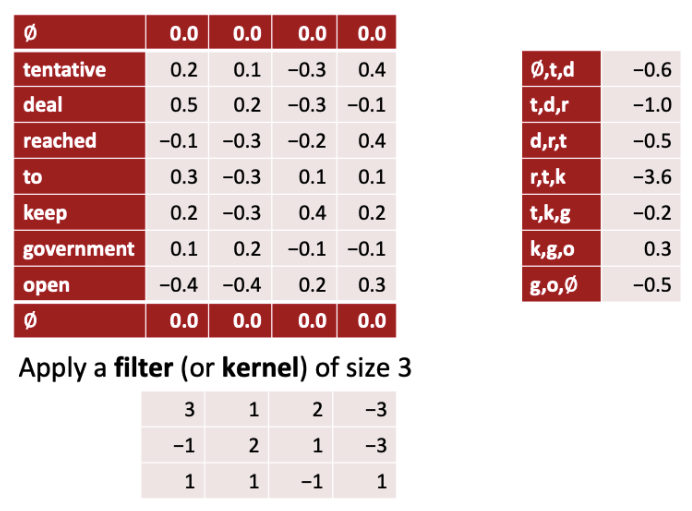

Importamos lo necesario

In [ ]:
import tensorflow as tf
import numpy as np

Definimos la entrada

In [ ]:
x = np.array([
    [0.2, 0.1, -0.3, 0.4],
    [0.5, 0.2, -0.3, -0.1],
    [-0.1, -0.3, -0.2, 0.4],
    [0.3, -0.3, 0.1, 0.1],
    [0.2, -0.3, 0.4, 0.2],
    [0.1, 0.2, -0.1, -0.1],
    [-0.4, -0.4, 0.2, 0.3]
], dtype=np.float32)

Le añadimos el batch

Keras Conv1D espera (batch, steps, channels)

Entonces vamos de (7,4) a (1,4,7)

In [ ]:
x = np.expand_dims(x, axis=0)

print("Shape: ", x.shape)
print("X: ", x)

Shape:  (1, 7, 4)
X:  [[[ 0.2  0.1 -0.3  0.4]
  [ 0.5  0.2 -0.3 -0.1]
  [-0.1 -0.3 -0.2  0.4]
  [ 0.3 -0.3  0.1  0.1]
  [ 0.2 -0.3  0.4  0.2]
  [ 0.1  0.2 -0.1 -0.1]
  [-0.4 -0.4  0.2  0.3]]]


Definimos el filtro

(kernel_size, in_channels, out_channels)

In [ ]:
filters = np.array([
    [[3], [1], [2], [-3]],
    [[-1],[2], [1], [-3]],
    [[1], [1],[-1],  [1]]], dtype=np.float32)

print(filters.shape)

(3, 4, 1)


Definimos la Conv1D

In [ ]:
conv_layer = tf.keras.layers.Conv1D(
    filters=1,
    kernel_size=3,
    padding='same',
    use_bias=False
)

Construimos la capa

In [ ]:
_ = conv_layer(x)

Asignamos los pesos manualmente (filtro)

In [ ]:
conv_layer.set_weights([filters])

Realizamos el forward propagation

In [ ]:
conv_output = conv_layer(x)

print(conv_output.numpy())

[[[-0.6       ]
  [-1.        ]
  [-0.5       ]
  [-3.6000001 ]
  [-0.19999999]
  [ 0.3       ]
  [-0.5       ]]]


Aplicamos MaxPooling1D

In [ ]:
global_max_pool = tf.keras.layers.GlobalMaxPooling1D()
max_pool_output = global_max_pool(conv_output)

print(max_pool_output.numpy())

[[0.3]]
